In [ ]:
#| hide
#| eval: false
! [ -e /content ] && pip install -Uqq fastai rawpy  # upgrade fastai on colab

In [ ]:
#| default_exp vision.raw
#| default_cls_lvl 3

In [ ]:
#| export
from fastai.basics import *
from fastai.vision.all import *

import rawpy

In [ ]:
#| hide
from nbdev.showdoc import *

# Vision RAW

> Open camera RAW files (DNG, CR2, NEF, ARW, ...) as linear float tensors that keep the sensor's 16-bit precision, using rawpy

A RAW file holds the sensor data as the camera captured it, before the tone curve, the white balance and the 8-bit JPEG quantisation are applied. [rawpy](https://letmaik.github.io/rawpy/) (a wrapper of LibRaw) demosaics it into 16-bit RGB. This module turns such files into `TensorRawImage`, a `TensorImage` subclass, so every batch transform, `Normalize`, `show_batch` and `show_results` work unchanged.

Like `fastai.medical.imaging`, this module is not imported by `fastai.vision.all`: install rawpy (`pip install rawpy`) and `from fastai.vision.raw import *`.

## Finding RAW files

In [ ]:
#| export
raw_extensions = {'.3fr','.arw','.cr2','.cr3','.crw','.dcr','.dng','.erf','.iiq','.k25','.kdc','.mef','.mos','.mrw',
                  '.nef','.nrw','.orf','.pef','.raf','.rw2','.rwl','.sr2','.srf','.srw'}

These are the extensions of the formats LibRaw reads (see the [supported cameras](https://www.libraw.org/supported-cameras) list). `image_extensions` comes from the operating system's mimetypes table, so on Debian-based systems `get_image_files` already returns `.cr2`, `.nef` and `.orf` files (which `PILImage.create` cannot open) and on other systems it does not; this list is explicit so `get_raw_files` behaves the same everywhere.

In [ ]:
#| export
def get_raw_files(path, recurse=True, folders=None):
    "Get RAW camera files in `path` recursively, only in `folders`, if specified."
    return get_files(path, extensions=raw_extensions, recurse=recurse, folders=folders)

`images/sample.dng` is a synthetic 64x48 linear (non-mosaic) 16-bit DNG built with numpy for the tests: a gradient band over the top 32 rows and a row of four solid blocks (red, green, blue, mid-grey) below it, with a colour matrix and white balance chosen so that rawpy returns the stored values. The generator is in the pull request that added it.

In [ ]:
TEST_RAW = Path('images/sample.dng')
test_eq(get_raw_files('images'), [TEST_RAW])
test_eq(get_raw_files('images', recurse=False), [TEST_RAW])

## TensorRawImage

The RAW item is the tensor itself, like `TensorPoint`: Pillow has no 16-bit RGB mode (`PILBase.create` converts arrays with `Image.fromarray`) and torch has no usable uint16 dtype, so the file is decoded straight to a float32 `TensorImage` subclass with values in [0,1]. There is no PIL wrapper class, and `ToTensor` has nothing to do.

In [ ]:
#| export
_raw_defaults = dict(gamma=(1,1), no_auto_bright=True, output_bps=16, use_camera_wb=True)

In [ ]:
#| export
class TensorRawImage(TensorImage):
    "A `TensorImage` decoded from a camera RAW file by rawpy: float32, channels first, values in [0,1]"
    @classmethod
    def create(cls, fn:Path|str|bytes, **kwargs):
        "Open RAW file `fn` (path or bytes) and postprocess it with rawpy `kwargs` (defaults: linear, 16-bit, camera white balance)"
        p = {**_raw_defaults, **kwargs}
        with rawpy.imread(io.BytesIO(fn) if isinstance(fn,bytes) else str(fn)) as raw: x = raw.postprocess(**p)
        return cls(torch.from_numpy(x.astype(np.float32)/(2**p['output_bps']-1)).permute(2,0,1))

In [ ]:
show_doc(TensorRawImage.create)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/vision/raw.py#L32){target="_blank" style="float:right; font-size:smaller"}

### TensorRawImage.create

```python
def create(
    fn:pathlib.Path | str | bytes, **kwargs
):
```

*Open RAW file `fn` (path or bytes) and postprocess it with rawpy `kwargs` (defaults: linear, 16-bit, camera white balance)*

The defaults keep the data linear and deterministic:

- `gamma=(1,1)`: no tone curve, so values stay proportional to scene radiance (the reason to train on RAW at all)
- `no_auto_bright=True`: no per-file histogram rescaling, so input/target pairs stay consistent
- `output_bps=16`: keeps the sensor precision
- `use_camera_wb=True`: applies the white balance multipliers recorded by the camera, which is deterministic per file

Any other [`rawpy.Params`](https://letmaik.github.io/rawpy/api/rawpy.Params.html) keyword passes through: `half_size=True` decodes mosaic (Bayer) files at half resolution in a quarter of the memory (a 24 MP frame is 288 MB as float32 CHW), `user_flip=0` disables the EXIF rotation, `demosaic_algorithm=rawpy.DemosaicAlgorithm.AHD` picks the demosaicer, and `gamma=(2.222,4.5)` gives display-referred output.

In [ ]:
t = TensorRawImage.create(TEST_RAW)
test_eq(type(t), TensorRawImage)
test_eq(t.dtype, torch.float32)
test_eq(t.shape, (3,48,64))
test_close(t.min().item(), 0., eps=1e-4)
test_close(t.max().item(), 1., eps=1e-4)
test_close(t[:,40,8],  tensor([1.,0.,0.]), eps=1e-3)   # solid blocks in the lower band
test_close(t[:,40,24], tensor([0.,1.,0.]), eps=1e-3)
test_close(t[:,40,40], tensor([0.,0.,1.]), eps=1e-3)
test_close(t[:,40,56], tensor([32768/65535]*3), eps=1e-4)   # mid grey: an 8-bit path would give 128/255
test_close(t[0,0,63].item(), 1., eps=1e-4)   # red ramp along row 0
test_eq(TensorRawImage.create(TEST_RAW.read_bytes()), t)
with expect_fail(): TensorRawImage.create(TEST_IMAGE)

### Showing

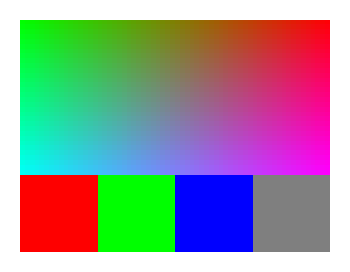

In [ ]:
ax = t.show(figsize=(2,2))
test_fig_exists(ax)

`TensorImage.show` hands the array to matplotlib, which displays float RGB in [0,1] as is, so no `show` override is needed. Linear data looks darker than a camera JPEG because no gamma curve was applied; pass `gamma=(2.222,4.5)` to `create` for display-like previews.

## Transforms

In [ ]:
#| exporti
@IntToFloatTensor
def encodes(self, o:TensorRawImage): return o
@IntToFloatTensor
def decodes(self, o:TensorRawImage): return o.clamp(0.,1.)

`TensorRawImage.create` already returns floats in [0,1], so `IntToFloatTensor` must not divide them again, and its decode only clamps for display (the default `decodes` would quantise to 8-bit longs; the clamp matters after `Normalize.decodes`, which can leave values slightly outside [0,1]).

We register methods for the subclass rather than giving `RawImageBlock` its own `IntToFloatTensor(div=65535.)` because `DataBlock` keeps a single instance per transform class across all blocks: a RAW input block and a PIL target block in one `DataBlock` would otherwise share whichever instance came last, and one side would be scaled twice or not at all. With the subclass dispatch there is one `IntToFloatTensor` per `DataBlock`: `/255` for `TensorImage`, identity for `TensorRawImage`. `ToTensor` has no `encodes` for tensors and passes them through.

In [ ]:
tfm = IntToFloatTensor()
test_eq(tfm(t), t); test_eq(type(tfm(t)), TensorRawImage)
test_eq(tfm.decode(t), t); test_eq(tfm.decode(t).dtype, torch.float32)
im = TensorImage(torch.full((3,2,2), 255, dtype=torch.uint8))
x,y = tfm((im, t))
test_eq(x, torch.ones(3,2,2)); test_eq(y, t)
test_eq(ToTensor()(t), t)

## RawImageBlock

In [ ]:
#| export
class RawImageCreate(Transform):
    "Open a RAW file as a `TensorRawImage`, passing `kwargs` to `TensorRawImage.create`"
    input_types = (Path,str,bytes)
    def __init__(self, **kwargs): self.kwargs = kwargs
    def encodes(self, fn:Path|str|bytes): return TensorRawImage.create(fn, **self.kwargs)

def RawImageBlock(**kwargs):
    "A `TransformBlock` for RAW camera images; `kwargs` are passed to `TensorRawImage.create`"
    return TransformBlock(type_tfms=RawImageCreate(**kwargs), batch_tfms=IntToFloatTensor)

`RawImageBlock` mirrors `ImageBlock`. `RawImageCreate` holds the rawpy keyword arguments as plain attributes so the block pickles for DataLoader workers and `Learner.export`, and `input_types` lets `learn.predict` accept a path, a string or bytes like `ImageBlock` does. `batch_tfms=IntToFloatTensor` is kept on purpose: a RAW-only `DataBlock` then has the same batch pipeline as a PIL one (the transform is a no-op for RAW, `Normalize` and the augmentations sit after it as usual), and a mixed RAW/PIL `DataBlock` gets the single shared instance discussed above. `type_tfms` are per block, so input and target may use different postprocessing parameters of the same file.

In [ ]:
def _items(p): return [TEST_RAW]*4
def _lbl(o): return 'a'
test_eq(type(pickle.loads(pickle.dumps(RawImageCreate(half_size=True)))), RawImageCreate)

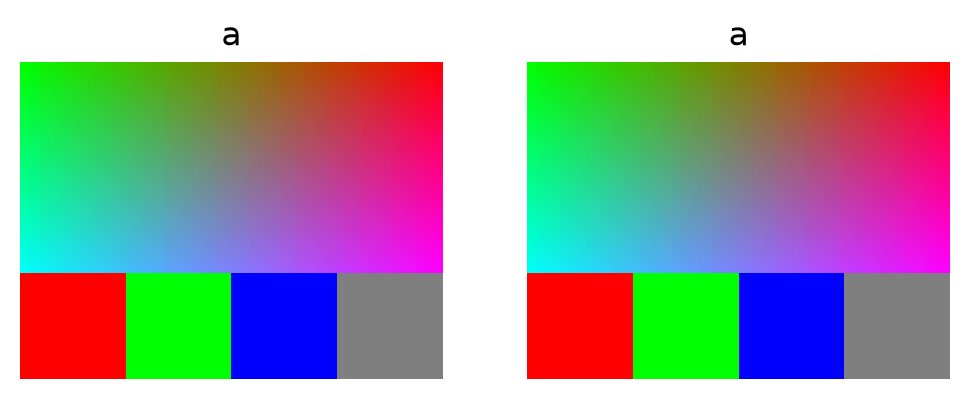

In [ ]:
raws = DataBlock(blocks=(RawImageBlock(), CategoryBlock), get_items=_items, get_y=_lbl, splitter=IndexSplitter([3]))
dls = raws.dataloaders('.', bs=2, num_workers=0)
x,y = dls.one_batch()
test_eq(type(x), TensorRawImage); test_eq(x.shape, (2,3,48,64)); test_eq(x.dtype, torch.float32)
dls.show_batch(max_n=2)

In [ ]:
dls = raws.new(item_tfms=Resize(32)).dataloaders('.', bs=2, num_workers=0)
x,y = dls.one_batch()
test_eq(x.shape, (2,3,32,32)); test_eq(type(x), TensorRawImage)

Item transforms such as `Resize` and `RandomResizedCrop` work directly on the tensor (they accept `TensorImageBase` items), which is how full-resolution RAW files should be cut down before batching. When all files come from one camera they share a size, so the batch-level `aug_transforms(size=...)` route also works without any item transform (`DataBlock.new` rebuilds the item and batch transforms from the block defaults each time):

In [ ]:
dls = raws.new(batch_tfms=[*aug_transforms(size=32), Normalize()]).dataloaders('.', bs=2, num_workers=0)
x,y = dls.one_batch()
test_eq(x.shape, (2,3,32,32)); test_eq(type(x), TensorRawImage)

## RAW to RAW

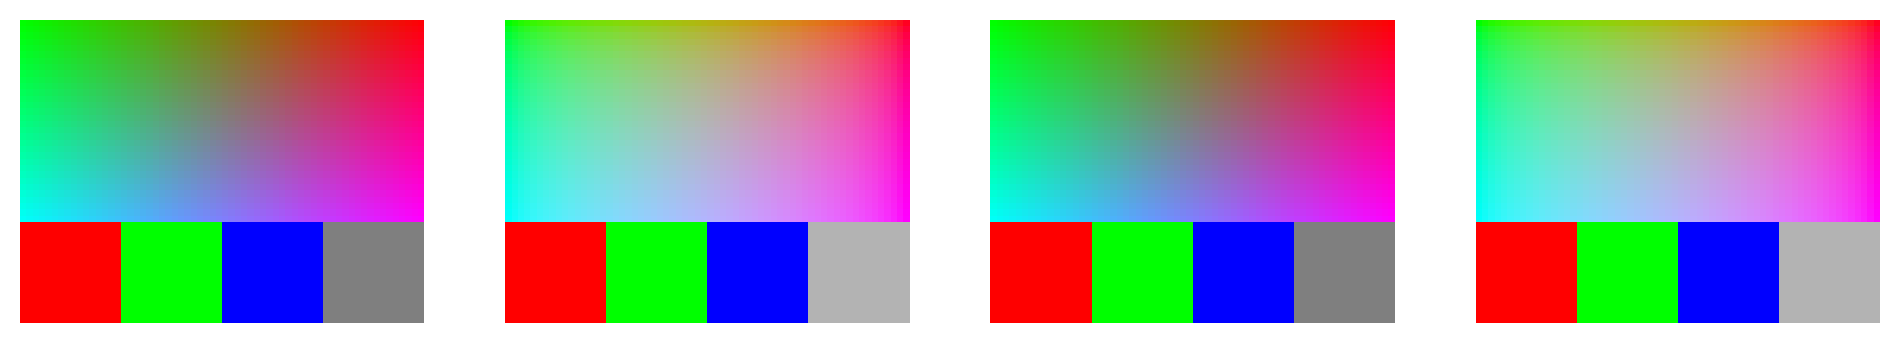

In [ ]:
pairs = DataBlock(blocks=(RawImageBlock(), RawImageBlock(gamma=(2.222,4.5))), get_items=_items, splitter=IndexSplitter([3]))
dls = pairs.dataloaders('.', bs=2, num_workers=0)
x,y = dls.one_batch()
test_eq(x.shape, y.shape); test_eq(type(y), TensorRawImage)
assert y.mean() > x.mean()   # the gamma-encoded target is brighter than the linear input
dls.show_batch(max_n=2)

## Usage

Classification from a folder of RAW files, one class per subfolder:

```python
from fastai.vision.all import *
from fastai.vision.raw import *

path = Path('data/shoot')   # class folders holding .cr2/.nef/.dng files
dblock = DataBlock(blocks=(RawImageBlock(half_size=True), CategoryBlock),
                   get_items=get_raw_files, get_y=parent_label, splitter=RandomSplitter(seed=42),
                   item_tfms=RandomResizedCrop(512, min_scale=0.5),
                   batch_tfms=[*aug_transforms(flip_vert=True, max_lighting=0), Normalize()])
dls = dblock.dataloaders(path, bs=8)
dls.show_batch()
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(3)
learn.show_results()
```

`Normalize()` without stats computes them from your data; `imagenet_stats` describe gamma-encoded JPEGs, and `vision_learner` only adds them when no `Normalize` is present. `max_lighting=0` keeps the radiometric relation between images.

RAW to RAW, with a different postprocessing of the same file as the target (for example to learn a display rendering; use `get_x`/`get_y` for short/long exposure pairs):

```python
dblock = DataBlock(blocks=(RawImageBlock(), RawImageBlock(gamma=(2.222,4.5))),   # linear input, display-referred target
                   get_items=get_raw_files, splitter=RandomSplitter(),
                   item_tfms=RandomResizedCrop(256, min_scale=0.5),
                   batch_tfms=[*aug_transforms(max_lighting=0), Normalize()])
dls = dblock.dataloaders(path, bs=4)
learn = unet_learner(dls, resnet18, n_out=3, loss_func=MSELossFlat())
learn.fit_one_cycle(5)
learn.show_results()
```

Decode mosaic files with `half_size=True` or crop at item level; never batch full-resolution frames.

## Export -

In [ ]:
#| hide
from nbdev import nbdev_export
nbdev_export()